In [2]:
#!/usr/bin/env python3

# Menyesuaikan path agar dapat mengimpor modul dari direktori utama (induk)
# tanpa mengubah struktur direktori proyek
import sys
sys.path.append('..')

# Mengimpor file module untuk melakukan sync semua file
# pada direktori utama (induk)
import module

Proses deteksi apex dibutuhkan untuk mendapatkan rentang temporal yang akan digunakan pada proses deteksi ekspresi mikro yang memiliki fokus pada representasi gerakan

In [3]:
import os
from pathlib import Path


# Sumber data utama
BASE_DATASOURCE_PATH= os.path.join(Path.home().as_posix(), "datasets", "primary-converted")

# Sumber data kelas yang diambil pada 08/12/2025
# Terdapat dua tipe data (before dan after)
BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH=os.path.join(BASE_DATASOURCE_PATH, "8-12-2025")

# Sumber data kelas yang diambil pada 09/12/2025
# Terdapat dua tipe data (before dan after)
BASE_SUBJECT_GROUP_09122025_BEFORE_AFTER_PATH=os.path.join(BASE_DATASOURCE_PATH, "9-12-2025")


# Verifikasi apakah path benar ada atau tidak
assert os.path.exists(BASE_DATASOURCE_PATH), f"Path tidak ditemukan: {BASE_DATASOURCE_PATH}"
assert os.path.exists(BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH), f"Path tidak ditemukan: {BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH}"
assert os.path.exists(BASE_SUBJECT_GROUP_09122025_BEFORE_AFTER_PATH), f"Path tidak ditemukan: {BASE_SUBJECT_GROUP_09122025_BEFORE_AFTER_PATH}"

print("Datasource path successfully set.")

Datasource path successfully set.


In [4]:
# Contoh video subjek untuk validasi teknik untuk memperoleh frame apex
validation_subject_video = os.path.join(BASE_SUBJECT_GROUP_08122025_BEFORE_AFTER_PATH, "aaisyah_nursalsabiil_ni_patriarti_1765168488512", "q1", "answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec.avi")

# Validasi keberadaan video subjek untuk validasi teknik
assert os.path.exists(validation_subject_video), f"Video tidak ditemukan: {validation_subject_video}"

Ekstraksi fase apex pada dataset primer yang sudah dikumpulkan

W0000 00:00:1770374483.290367  130666 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770374483.296981  130668 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770374483.312973  130668 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


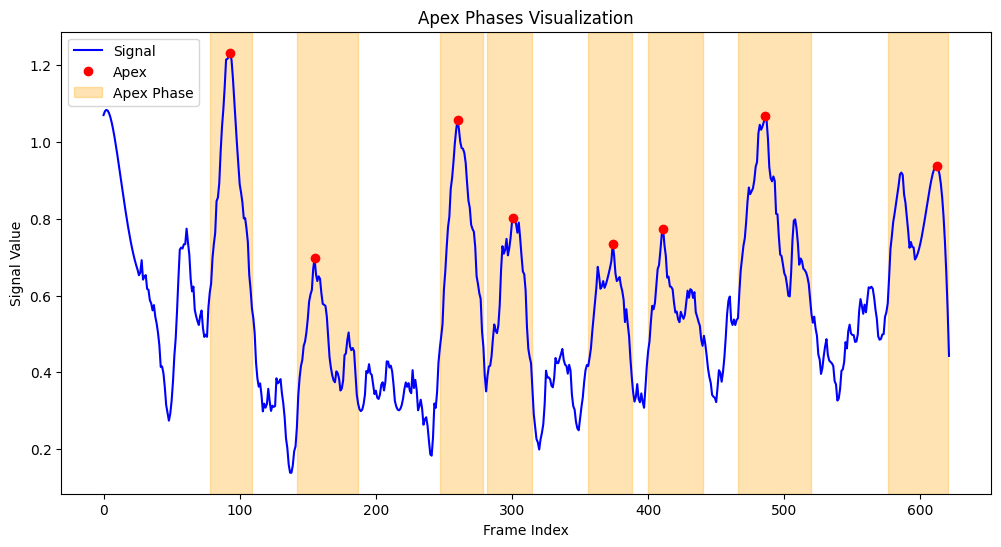

In [7]:
# Ekstraksi magnitudo pada keseluruhan wajah

import numpy as np
from scipy.signal import savgol_filter
from src.video.modules import Video
from src.face.modules import FaceLandmark
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer


face_landmark = FaceLandmark()

tvl1 = TVL1()

magnitudes = []

def process(prev_frame: np.ndarray, curr_frame: np.ndarray, frame_index: int) -> np.ndarray:

    prev_landmarks = face_landmark.detect(prev_frame)
    curr_landmarks = face_landmark.detect(curr_frame)

    prev_face = face_landmark.crop(image=prev_frame.copy(), landmarks=prev_landmarks)
    curr_face = face_landmark.crop(image=curr_frame.copy(), landmarks=curr_landmarks)

    flow = tvl1.compute(prev_face, curr_face)

    dx = flow[..., 0]
    dy = flow[..., 1]

    magnitude = np.sqrt(dx**2 + dy**2)

    mean_magnitude = np.mean(magnitude)

    magnitudes.append(mean_magnitude)


apex_phase = ApexPhase(distance_threshold=11, prominence_threshold=0.3)

video = Video(video_path=validation_subject_video)
video.map(process)

window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_indices = apex_phase.find_apex(signal=smoothed_magnitudes)

phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apex_indices)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases(signal=smoothed_magnitudes,
                                  phases=phases,
                                  apex_indices=apex_indices)

W0000 00:00:1770967640.237870   80964 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770967640.243217   80971 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770967640.253376   80976 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


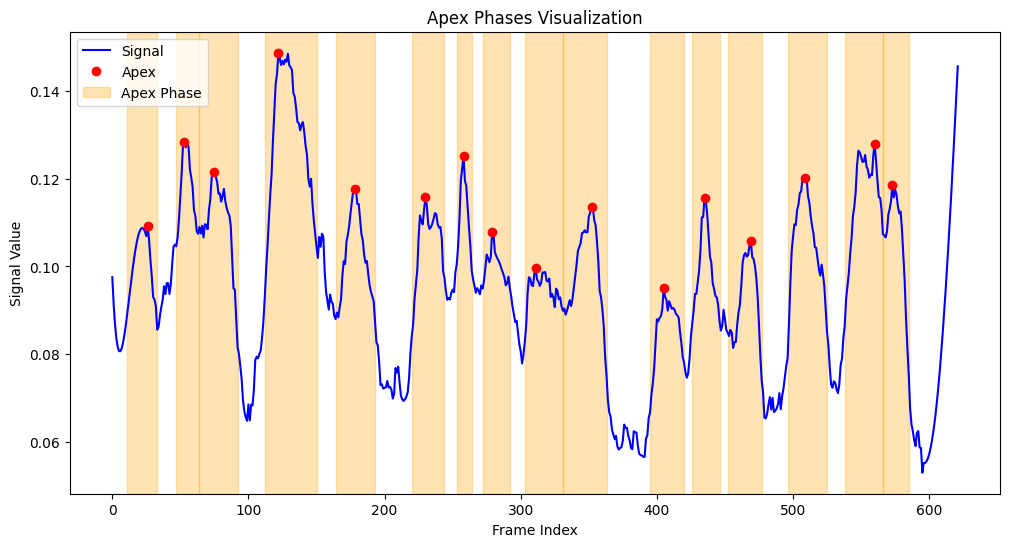

In [6]:
# Ekstraksi magnitudo pada keseluruhan wajah

import numpy as np
from scipy.signal import savgol_filter
from src.video.modules import Video
from src.face.modules import FaceLandmark, FaceRoiPoints, FaceRoiSizes
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhase, ApexSmoother, ApexPhaseVisualizer


face_landmark = FaceLandmark()

tvl1 = TVL1()

magnitudes = []

def process(prev_frame: np.ndarray, curr_frame: np.ndarray, frame_index: int) -> np.ndarray:

    prev_landmarks = face_landmark.detect(prev_frame)
    curr_landmarks = face_landmark.detect(curr_frame)

    cropped_left_eye_prev, left_eye_roi_mask               = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eye_next, left_eye_roi_mask               = face_landmark.crop_roi(image=curr_frame.copy(),
                                                                                    landmark_result=curr_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_prev, right_eye_roi_mask             = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_right_eye_next, right_eye_roi_mask             = face_landmark.crop_roi(image=curr_frame.copy(),
                                                                                    landmark_result=curr_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                    target_size=FaceRoiSizes.EYE_SIZE)
    
    cropped_left_eyebrow_prev, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_left_eyebrow_next, left_eyebrow_roi_mask       = face_landmark.crop_roi(image=curr_frame.copy(),
                                                                                    landmark_result=curr_landmarks,
                                                                                    roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_prev, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)
    
    cropped_right_eyebrow_next, right_eyebrow_roi_mask     = face_landmark.crop_roi(image=curr_frame.copy(),
                                                                                    landmark_result=curr_landmarks,
                                                                                    roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                    target_size=FaceRoiSizes.EYEBROW_SIZE)

    cropped_lips_prev, lips_roi_mask                       = face_landmark.crop_roi(image=prev_frame.copy(),
                                                                                    landmark_result=prev_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    
    cropped_lips_next, lips_roi_mask                       = face_landmark.crop_roi(image=curr_frame.copy(),
                                                                                    landmark_result=curr_landmarks,
                                                                                    roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                    target_size=FaceRoiSizes.LIPS_SIZE)
    

    flow_left_eye           = tvl1.compute(cropped_left_eye_prev, cropped_left_eye_next)
    flow_right_eye          = tvl1.compute(cropped_right_eye_prev, cropped_right_eye_next)
    flow_left_eyebrow       = tvl1.compute(cropped_left_eyebrow_prev, cropped_left_eyebrow_next)
    flow_right_eyebrow      = tvl1.compute(cropped_right_eyebrow_prev, cropped_right_eyebrow_next)
    flow_lips               = tvl1.compute(cropped_lips_prev, cropped_lips_next)

    flow_left_eye[..., 0]    *= (left_eye_roi_mask > 0)
    flow_left_eye[..., 1]    *= (left_eye_roi_mask > 0)

    flow_right_eye[..., 0]   *= (right_eye_roi_mask > 0)
    flow_right_eye[..., 1]   *= (right_eye_roi_mask > 0)

    flow_left_eyebrow[..., 0]    *= (left_eyebrow_roi_mask > 0)
    flow_left_eyebrow[..., 1]    *= (left_eyebrow_roi_mask > 0)

    flow_right_eyebrow[..., 0]   *= (right_eyebrow_roi_mask > 0)
    flow_right_eyebrow[..., 1]   *= (right_eyebrow_roi_mask > 0)

    flow_lips[..., 0]    *= (lips_roi_mask > 0)
    flow_lips[..., 1]    *= (lips_roi_mask > 0)

    magnitude_left_eye          = np.sqrt(flow_left_eye[..., 0]**2 + flow_left_eye[..., 1]**2)
    magnitude_right_eye         = np.sqrt(flow_right_eye[..., 0]**2 + flow_right_eye[..., 1]**2)
    magnitude_left_eyebrow      = np.sqrt(flow_left_eyebrow[..., 0]**2 + flow_left_eyebrow[..., 1]**2)
    magnitude_right_eyebrow     = np.sqrt(flow_right_eyebrow[..., 0]**2 + flow_right_eyebrow[..., 1]**2)
    magnitude_lips              = np.sqrt(flow_lips[..., 0]**2 + flow_lips[..., 1]**2)

    mean_magnitude_left_eye        = np.mean(magnitude_left_eye)
    mean_magnitude_right_eye       = np.mean(magnitude_right_eye)
    mean_magnitude_left_eyebrow    = np.mean(magnitude_left_eyebrow)
    mean_magnitude_right_eyebrow   = np.mean(magnitude_right_eyebrow)
    mean_magnitude_lips            = np.mean(magnitude_lips)

    mean_magnitude = np.mean([
        mean_magnitude_left_eye,
        mean_magnitude_right_eye,
        mean_magnitude_left_eyebrow,
        mean_magnitude_right_eyebrow,
        mean_magnitude_lips
    ])

    magnitudes.append(mean_magnitude)


apex_phase = ApexPhase(distance_threshold=11)

video = Video(video_path=validation_subject_video)
video.map(process)

window_length = ApexSmoother.calculate_window_length(len(magnitudes))

polyorder = ApexSmoother.calculate_polyorder(window_length)

smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

apex_indices = apex_phase.find_apex(signal=smoothed_magnitudes)

phases = apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apex_indices)

apex_phase_visualizer = ApexPhaseVisualizer()

apex_phase_visualizer.plot_phases(signal=smoothed_magnitudes,
                                  phases=phases,
                                  apex_indices=apex_indices)

Membuat blueprint untuk centralisasi deteksi fase apex

In [9]:
import numpy as np
from typing import List, Tuple
from src.video.modules import Video
from scipy.signal import savgol_filter
from src.face.modules import FaceRoiPoints, FaceRoiSizes
from src.face.modules import FaceLandmark
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhase, ApexSmoother


class ApexPhaseSpotter:

    def __init__(self, distance_threshold: int = 11, prominence_threshold: float = 0.01):
        """
        Inisialisasi instance untuk deteksi fase apex pada sebuah video

        Args:
            distance_threshold (int): Jarak minimum antara puncak apex yang terdeteksi.
            prominence_threshold (float): Ambang batas prominensi untuk mendeteksi puncak apex.
        """
    
        self.landmarker = FaceLandmark()

        self.tvl1 = TVL1()

        self.apex_phase = ApexPhase(distance_threshold=distance_threshold,
                                    prominence_threshold=prominence_threshold)
        
        self.magnitudes = []

    
    def process(self, video_path: str) -> Tuple[List[int], List[int]]:
        """
        Memproses video untuk mendeteksi indeks apex dan fase

        Args:
            video_path (str): Path ke file video yang akan diproses

        Returns:
            Tuple[List[int], List[int]]: Indeks apex dan fase yang terdeteksi
        """

        video = Video(video_path=video_path)

        video.map(self.__process_with_roi)

        apex_indices, phases = self.__find_apex_phase(self.magnitudes)

        return apex_indices, phases

    
    def __process_with_roi(self, prev_frame: np.ndarray, curr_frame: np.ndarray, frame_index: int) -> np.ndarray:

        prev_landmarks = self.landmarker.detect(prev_frame)
        curr_landmarks = self.landmarker.detect(curr_frame)

        cropped_left_eye_prev, left_eye_roi_mask               = self.landmarker.crop_roi(image=prev_frame.copy(),
                                                                                          landmark_result=prev_landmarks,
                                                                                          roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                          target_size=FaceRoiSizes.EYE_SIZE)
        
        cropped_left_eye_next, left_eye_roi_mask               = self.landmarker.crop_roi(image=curr_frame.copy(),
                                                                                          landmark_result=curr_landmarks,
                                                                                          roi_points=FaceRoiPoints.LEFT_EYE_POINTS,
                                                                                          target_size=FaceRoiSizes.EYE_SIZE)
        
        cropped_right_eye_prev, right_eye_roi_mask             = self.landmarker.crop_roi(image=prev_frame.copy(),
                                                                                          landmark_result=prev_landmarks,
                                                                                          roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                          target_size=FaceRoiSizes.EYE_SIZE)
        
        cropped_right_eye_next, right_eye_roi_mask             = self.landmarker.crop_roi(image=curr_frame.copy(),
                                                                                          landmark_result=curr_landmarks,
                                                                                          roi_points=FaceRoiPoints.RIGHT_EYE_POINTS,
                                                                                          target_size=FaceRoiSizes.EYE_SIZE)
        
        cropped_left_eyebrow_prev, left_eyebrow_roi_mask       = self.landmarker.crop_roi(image=prev_frame.copy(),
                                                                                          landmark_result=prev_landmarks,
                                                                                          roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                          target_size=FaceRoiSizes.EYEBROW_SIZE)
        
        cropped_left_eyebrow_next, left_eyebrow_roi_mask       = self.landmarker.crop_roi(image=curr_frame.copy(),
                                                                                          landmark_result=curr_landmarks,
                                                                                          roi_points=FaceRoiPoints.LEFT_EYEBROW_POINTS,
                                                                                          target_size=FaceRoiSizes.EYEBROW_SIZE)
        
        cropped_right_eyebrow_prev, right_eyebrow_roi_mask     = self.landmarker.crop_roi(image=prev_frame.copy(),
                                                                                          landmark_result=prev_landmarks,
                                                                                          roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                          target_size=FaceRoiSizes.EYEBROW_SIZE)
        
        cropped_right_eyebrow_next, right_eyebrow_roi_mask     = self.landmarker.crop_roi(image=curr_frame.copy(),
                                                                                          landmark_result=curr_landmarks,
                                                                                          roi_points=FaceRoiPoints.RIGHT_EYEBROW_POINTS,
                                                                                          target_size=FaceRoiSizes.EYEBROW_SIZE)
        
        cropped_lips_prev, lips_roi_mask                       = self.landmarker.crop_roi(image=prev_frame.copy(),
                                                                                          landmark_result=prev_landmarks,
                                                                                          roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                          target_size=FaceRoiSizes.LIPS_SIZE)
        
        cropped_lips_next, lips_roi_mask                       = self.landmarker.crop_roi(image=curr_frame.copy(),
                                                                                          landmark_result=curr_landmarks,
                                                                                          roi_points=FaceRoiPoints.LIPS_POINTS,
                                                                                          target_size=FaceRoiSizes.LIPS_SIZE)
        
        flow_left_eye           = self.tvl1.compute(cropped_left_eye_prev, cropped_left_eye_next)
        flow_right_eye          = self.tvl1.compute(cropped_right_eye_prev, cropped_right_eye_next)
        flow_left_eyebrow       = self.tvl1.compute(cropped_left_eyebrow_prev, cropped_left_eyebrow_next)
        flow_right_eyebrow      = self.tvl1.compute(cropped_right_eyebrow_prev, cropped_right_eyebrow_next)
        flow_lips               = self.tvl1.compute(cropped_lips_prev, cropped_lips_next)

        flow_left_eye[..., 0]    *= (left_eye_roi_mask > 0)
        flow_left_eye[..., 1]    *= (left_eye_roi_mask > 0)

        flow_right_eye[..., 0]   *= (right_eye_roi_mask > 0)
        flow_right_eye[..., 1]   *= (right_eye_roi_mask > 0)

        flow_left_eyebrow[..., 0]    *= (left_eyebrow_roi_mask > 0)
        flow_left_eyebrow[..., 1]    *= (left_eyebrow_roi_mask > 0)

        flow_right_eyebrow[..., 0]   *= (right_eyebrow_roi_mask > 0)
        flow_right_eyebrow[..., 1]   *= (right_eyebrow_roi_mask > 0)

        flow_lips[..., 0]    *= (lips_roi_mask > 0)
        flow_lips[..., 1]    *= (lips_roi_mask > 0)

        magnitude_left_eye          = np.sqrt(flow_left_eye[..., 0]**2 + flow_left_eye[..., 1]**2)
        magnitude_right_eye         = np.sqrt(flow_right_eye[..., 0]**2 + flow_right_eye[..., 1]**2)
        magnitude_left_eyebrow      = np.sqrt(flow_left_eyebrow[..., 0]**2 + flow_left_eyebrow[..., 1]**2)
        magnitude_right_eyebrow     = np.sqrt(flow_right_eyebrow[..., 0]**2 + flow_right_eyebrow[..., 1]**2)
        magnitude_lips              = np.sqrt(flow_lips[..., 0]**2 + flow_lips[..., 1]**2)

        mean_magnitude_left_eye        = np.mean(magnitude_left_eye)
        mean_magnitude_right_eye       = np.mean(magnitude_right_eye)
        mean_magnitude_left_eyebrow    = np.mean(magnitude_left_eyebrow)
        mean_magnitude_right_eyebrow   = np.mean(magnitude_right_eyebrow)
        mean_magnitude_lips            = np.mean(magnitude_lips)

        mean_magnitude = np.mean([
            mean_magnitude_left_eye,
            mean_magnitude_right_eye,
            mean_magnitude_left_eyebrow,
            mean_magnitude_right_eyebrow,
            mean_magnitude_lips
        ])

        self.magnitudes.append(mean_magnitude)


    def __find_apex_phase(self, magnitudes: List[np.ndarray]) -> Tuple[List[int], List[int]]:
        """
        Mendeteksi indeks apex dan fase pada sinyal magnitudo

        Args:
            magnitudes (List[np.ndarray]): Daftar magnitudo yang telah dihaluskan

        Returns:
            Tuple[List[int], List[int]]: Indeks apex dan fase yang terdeteksi
        """
        window_length = ApexSmoother.calculate_window_length(len(magnitudes))

        polyorder = ApexSmoother.calculate_polyorder(window_length)

        smoothed_magnitudes = savgol_filter(magnitudes, window_length, polyorder)

        apex_indices = self.apex_phase.find_apex(signal=smoothed_magnitudes)

        phases = self.apex_phase.find_phase(signal=smoothed_magnitudes, apex_indices=apex_indices)

        return apex_indices, phases

In [12]:
spotter = ApexPhaseSpotter(distance_threshold=11, prominence_threshold=0.01)

apex_phase, phases = spotter.process(video_path=validation_subject_video)

print(apex_phase, phases)

W0000 00:00:1770967838.240496   81428 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1770967838.243611   81429 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770967838.254108   81429 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


[26, 53, 75, 122, 178, 230, 258, 279, 311, 352, 405, 435, 469, 509, 560, 573] {26: {'start': 11, 'end': 33}, 53: {'start': 47, 'end': 64}, 75: {'start': 64, 'end': 92}, 122: {'start': 112, 'end': 150}, 178: {'start': 164, 'end': 193}, 230: {'start': 220, 'end': 244}, 258: {'start': 253, 'end': 264}, 279: {'start': 272, 'end': 292}, 311: {'start': 303, 'end': 331}, 352: {'start': 331, 'end': 363}, 405: {'start': 395, 'end': 420}, 435: {'start': 426, 'end': 446}, 469: {'start': 452, 'end': 477}, 509: {'start': 496, 'end': 525}, 560: {'start': 538, 'end': 566}, 573: {'start': 566, 'end': 585}}
